# Mạng Nơ-ron Nhân tạo (ANN) với PyTorch trên MNIST

## Lý thuyết về ANN

- ANN (Artificial Neural Network) là mô hình gồm nhiều lớp nơ-ron nhân tạo.
- Dữ liệu đầu vào đi qua các lớp ẩn, sau đó tạo ra dự đoán ở đầu ra.
- Với MNIST, mỗi ảnh chữ số xám có kích thước **28 x 28**, nên khi đưa vào ANN sẽ được **làm phẳng (flatten)** thành vector có **784 đặc trưng**.


### 2. Cấu trúc ANN

- **Input layer**: 784 nút (ứng với 784 pixel).
- **Hidden layer 1**: 256 nút.
- **Hidden layer 2**: 128 nút.
- **Output layer**: 10 nút tương ứng 10 lớp chữ số từ 0 đến 9.


### 3. Trọng số và độ chệch

- **Trọng số (weights)** quyết định mức độ ảnh hưởng của từng đặc trưng đầu vào.
- **Bias** giúp mô hình linh hoạt hơn khi học ranh giới phân lớp.


### 4. Hàm kích hoạt

- Trong các lớp ẩn, dùng **ReLU** để giúp mạng học quan hệ phi tuyến.
- Ở đầu ra, không cần dùng Softmax trực tiếp trong mô hình nếu sử dụng `CrossEntropyLoss`, vì hàm mất mát này đã tự xử lý phần đó.


### 5. Lan truyền tiến (Forward Propagation)

Quy trình:

1. Ảnh đầu vào được làm phẳng từ `28x28` thành `784`.
2. Đi qua lớp ẩn 1 rồi kích hoạt ReLU.
3. Đi qua lớp ẩn 2 rồi kích hoạt ReLU.
4. Đi qua lớp đầu ra để tạo ra điểm số cho 10 lớp.


### 6. Hàm mất mát (Loss Function)

- Với bài toán phân loại nhiều lớp như MNIST, dùng **CrossEntropyLoss**.
- Hàm này đo mức độ sai khác giữa dự đoán của mô hình và nhãn thực tế.


### 7. Lan truyền ngược (Backpropagation)

- Sau khi tính loss, mô hình lan truyền lỗi ngược từ đầu ra về các lớp trước.
- Optimizer sẽ cập nhật trọng số để giảm sai số qua từng epoch.


In [1]:
# Cài đặt thư viện
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Đặt seed để kết quả ổn định hơn
torch.manual_seed(42)
np.random.seed(42)

# Chọn thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


### 8. Tối ưu hóa (Optimizer)

- Sử dụng **Adam** vì hội tụ nhanh và ổn định cho bài toán ANN cơ bản.


## Tạo dữ liệu từ MNIST


In [2]:
# Tiền xử lý dữ liệu
transform = transforms.ToTensor()

# Tải dữ liệu MNIST
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# Tách train / validation
train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size])

# DataLoader
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Số mẫu train:", len(train_dataset))
print("Số mẫu validation:", len(val_dataset))
print("Số mẫu test:", len(test_dataset))


100%|██████████| 9.91M/9.91M [00:11<00:00, 887kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 92.8kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.98MB/s]


Số mẫu train: 54000
Số mẫu validation: 6000
Số mẫu test: 10000


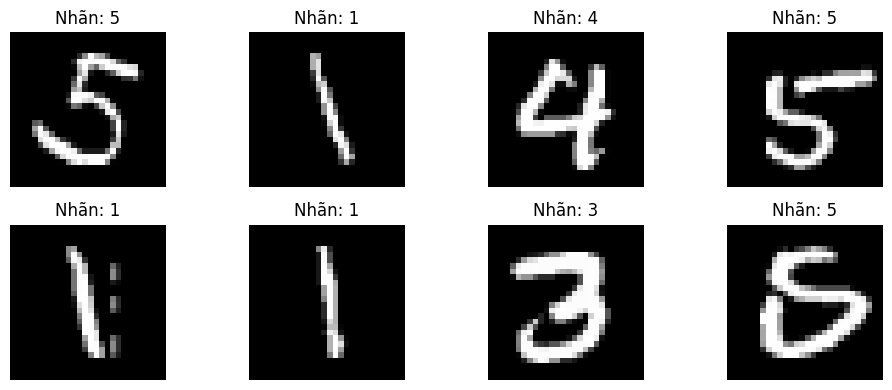

In [3]:
# Hiển thị một vài ảnh mẫu
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Nhãn: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Xây ANN bằng PyTorch

ANN đơn giản cho MNIST:


In [4]:
# Xây dựng mô hình ANN cho MNIST
class ANN_MNIST(nn.Module):
    def __init__(self):
        super(ANN_MNIST, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

# Khởi tạo mô hình
model = ANN_MNIST().to(device)

# Định nghĩa mất mát và tối ưu hóa
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)


ANN_MNIST(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [5]:
# Hàm đánh giá
def evaluate_model(model, dataloader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


In [6]:
# Huấn luyện
epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    running_correct = 0
    running_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_loss, val_acc = evaluate_model(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")


Epoch [1/10] | Train Loss: 0.4021 | Train Acc: 88.61% | Val Loss: 0.1872 | Val Acc: 94.30%
Epoch [2/10] | Train Loss: 0.1649 | Train Acc: 95.10% | Val Loss: 0.1290 | Val Acc: 96.13%
Epoch [3/10] | Train Loss: 0.1169 | Train Acc: 96.42% | Val Loss: 0.1079 | Val Acc: 96.85%
Epoch [4/10] | Train Loss: 0.0909 | Train Acc: 97.26% | Val Loss: 0.0901 | Val Acc: 97.23%
Epoch [5/10] | Train Loss: 0.0744 | Train Acc: 97.72% | Val Loss: 0.0878 | Val Acc: 97.37%
Epoch [6/10] | Train Loss: 0.0619 | Train Acc: 98.09% | Val Loss: 0.0823 | Val Acc: 97.62%
Epoch [7/10] | Train Loss: 0.0541 | Train Acc: 98.30% | Val Loss: 0.0816 | Val Acc: 97.53%
Epoch [8/10] | Train Loss: 0.0489 | Train Acc: 98.41% | Val Loss: 0.0761 | Val Acc: 97.65%
Epoch [9/10] | Train Loss: 0.0423 | Train Acc: 98.60% | Val Loss: 0.0699 | Val Acc: 97.88%
Epoch [10/10] | Train Loss: 0.0365 | Train Acc: 98.83% | Val Loss: 0.0759 | Val Acc: 97.82%


## Kiểm tra mô hình ANN

ANN đoán đúng bao nhiêu trên dữ liệu kiểm tra.


In [7]:
# Kiểm tra trên tập test
test_loss, test_acc = evaluate_model(model, test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Độ chính xác trên tập test: {test_acc*100:.2f}%")


Test Loss: 0.0703
Độ chính xác trên tập test: 97.96%


## Visualization


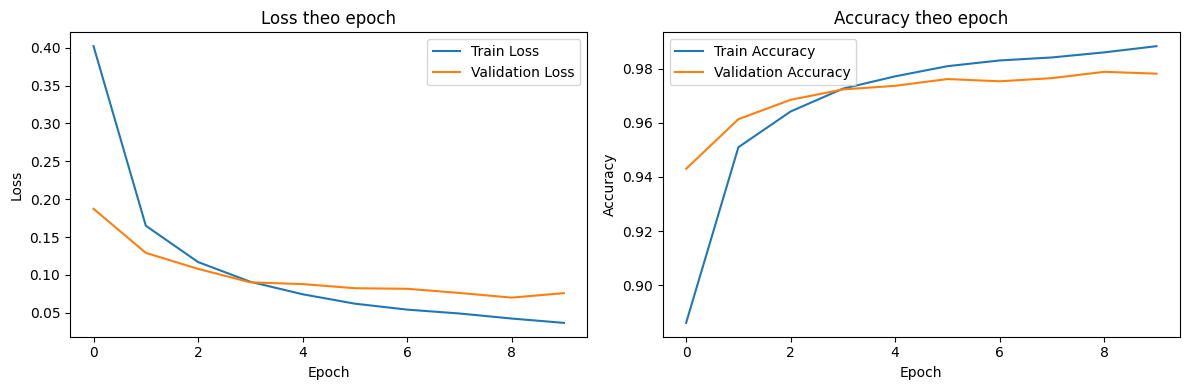

In [8]:
# Vẽ loss và accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss theo epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy theo epoch")
plt.legend()

plt.tight_layout()
plt.show()


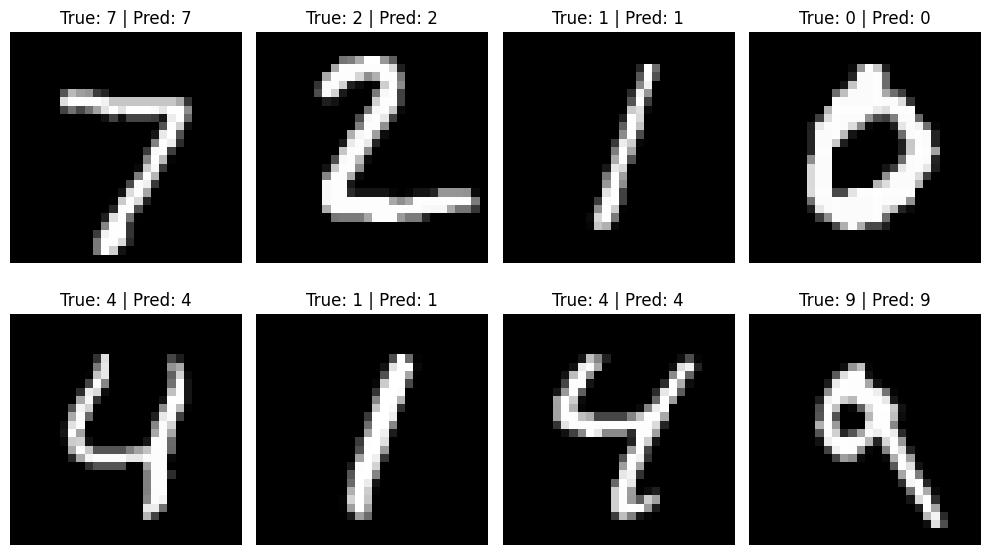

In [9]:
# Hiển thị dự đoán của mô hình trên một số ảnh test
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(f"True: {labels[i].item()} | Pred: {preds[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Kết luận

- ANN với PyTorch có thể học tốt trên bộ dữ liệu MNIST.
- Vì MNIST là dữ liệu ảnh đơn giản, ANN vẫn đạt độ chính xác khá cao.
- Tuy nhiên, với dữ liệu ảnh phức tạp hơn, CNN thường phù hợp hơn ANN.
